In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Device: {device}")
os.makedirs('../results', exist_ok=True)

# Recreate LSTM class — must match training exactly
class LSTMPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = 64
        self.layers = 2
        self.lstm = nn.LSTM(2, 64, 2, batch_first=True, dropout=0.1)
        self.drop = nn.Dropout(0.1)
        self.fc   = nn.Linear(64, 2)

    def forward(self, x):
        h0 = torch.zeros(self.layers, x.size(0), self.hidden).to(x.device)
        c0 = torch.zeros(self.layers, x.size(0), self.hidden).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(self.drop(out[:, -1, :]))

model = LSTMPredictor().to(device)
model.load_state_dict(torch.load('../models/lstm_best.pt', map_location=device))
model.eval()
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

# Load normalization scale from training
norm_data = np.load('../models/norm_params.npy', allow_pickle=True).item()
scale = norm_data['scale']
print(f"Scale factors: {scale}")

def norm(x):   return x / scale
def denorm(x): return x * scale


Device: mps
Parameters: 50818
Scale factors: [ 2. 18.]


### Generate Two Unseen Test Trajectories
These are deliberately different from training trajectories:
Training used: X=260m, Y=300-600m, straight/S-curve/L-turn

Test 1: Different X position (255m), zigzag motion

Test 2: Double turn (Z-shape) — completely new motion pattern

In [ ]:
import deepmimo as dm

# Load the scenario (already downloaded)
dataset  = dm.load('o1_60')
bs0      = dataset[0]
positions = bs0['rx_pos']   # (497931, 3)

print("Scenario loaded ✓")
print(f"Grid — X: {positions[:,0].min():.1f} to {positions[:,0].max():.1f}m")
print(f"       Y: {positions[:,1].min():.1f} to {positions[:,1].max():.1f}m")

def find_nearest_user(positions, x, y):
    dists = np.sqrt((positions[:,0]-x)**2 + (positions[:,1]-y)**2)
    return np.argmin(dists)

T = 200  # same length as training trajectories

# ── TEST TRAJECTORY 1: Zigzag ─────────────────────────────
# User walks down Y but oscillates rapidly in X (much faster than training S-curve)
# Training curve used sin with period=T. This zigzag uses period=T/5 — 5x faster
# Also uses a different X centre (255m vs 260m in training)
# This tests whether the model generalises to faster lateral oscillations
# at a different corridor position

x_centre_1 = 255.0   # different from training (260m)
zigzag_waypoints = [
    (x_centre_1 + 5.0 * np.sin(10 * np.pi * i / T),   # fast zigzag, ±5m in X
     650 + 150 * i / T)                                  # Y: 650→800m (unseen range)
    for i in range(T)
]
zigzag_indices = [find_nearest_user(positions, x, y) for x, y in zigzag_waypoints]
zigzag_pos     = positions[zigzag_indices]

# ── TEST TRAJECTORY 2: Double Turn (Z-shape) ───────────────
# Completely new motion pattern not seen during training.
# User walks down Y, turns right across X, then turns down Y again.
# Training only saw a single L-turn. This is a Z — two direction changes.

third = T // 3
double_turn_waypoints = (
    [(268.0, 400 + 100 * i / third) for i in range(third)]      # phase 1: down Y (X=268m, different position)
  + [(268.0 + 8 * i / third, 500)   for i in range(third)]      # phase 2: right across X
  + [(276.0, 500 + 150 * i / third) for i in range(third)]      # phase 3: down Y again
)
double_turn_indices = [find_nearest_user(positions, x, y) for x, y in double_turn_waypoints]
double_turn_pos     = positions[double_turn_indices]

print(f"\nZigzag trajectory:")
print(f"  First 3 positions: {zigzag_pos[:3, :2]}")
print(f"  X range: {zigzag_pos[:,0].min():.2f} to {zigzag_pos[:,0].max():.2f}m")
print(f"  Y range: {zigzag_pos[:,1].min():.2f} to {zigzag_pos[:,1].max():.2f}m")
print(f"\nDouble Turn (Z-shape) trajectory:")
print(f"  First 3 positions: {double_turn_pos[:3, :2]}")
print(f"  X range: {double_turn_pos[:,0].min():.2f} to {double_turn_pos[:,0].max():.2f}m")
print(f"  Y range: {double_turn_pos[:,1].min():.2f} to {double_turn_pos[:,1].max():.2f}m")

Loading TXRX PAIR: TXset 10 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 10 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 10 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 11 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 11 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 11 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 12 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 12 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 12 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 13 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 13 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 13 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 14 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 14 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 14 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TX

### Visualise the Two Test Trajectories

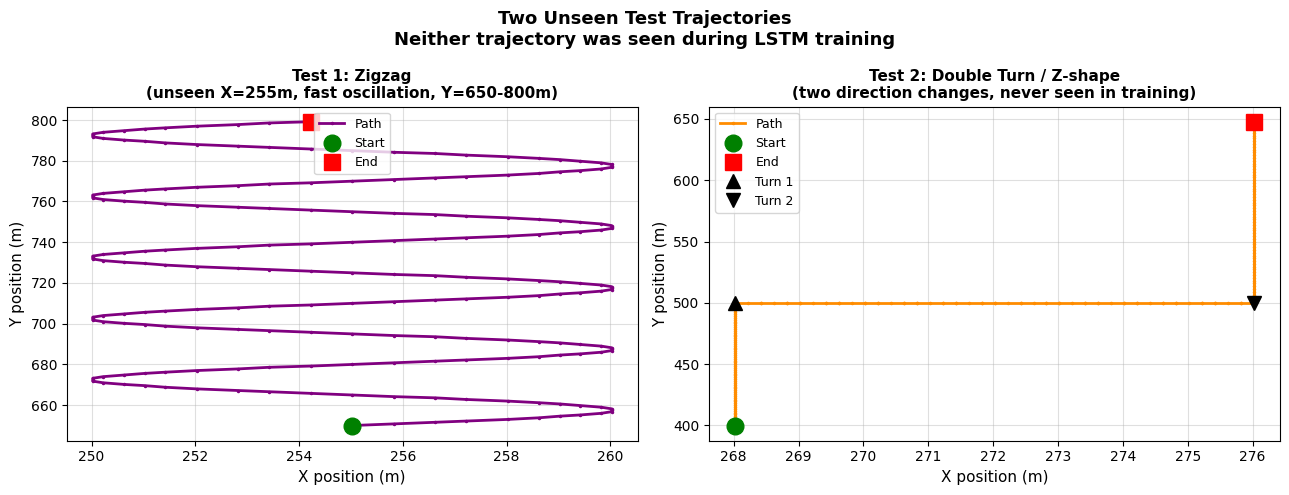

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pos, title, color in zip(axes,
    [zigzag_pos, double_turn_pos],
    ['Test 1: Zigzag\n(unseen X=255m, fast oscillation, Y=650-800m)',
     'Test 2: Double Turn / Z-shape\n(two direction changes, never seen in training)'],
    ['purple', 'darkorange']
):
    ax.plot(pos[:,0], pos[:,1], color=color, lw=2, marker='.', ms=3, label='Path')
    ax.plot(pos[0,0],  pos[0,1],  'go', ms=12, zorder=5, label='Start')
    ax.plot(pos[-1,0], pos[-1,1], 'rs', ms=12, zorder=5, label='End')

    # Mark the turn points for double turn
    if 'Double' in title:
        t1 = len(pos)//3
        t2 = 2*len(pos)//3
        ax.plot(pos[t1,0], pos[t1,1], 'k^', ms=10, zorder=5, label='Turn 1')
        ax.plot(pos[t2,0], pos[t2,1], 'kv', ms=10, zorder=5, label='Turn 2')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('X position (m)', fontsize=11)
    ax.set_ylabel('Y position (m)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle('Two Unseen Test Trajectories\n'
             'Neither trajectory was seen during LSTM training',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/test_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### Compute Channels for Test Trajectories

In [20]:
all_test_indices = list(set(zigzag_indices + double_turn_indices))
print(f"Unique test positions needed: {len(all_test_indices)}")

bs0_test     = bs0.trim(idxs=all_test_indices)
H_test_small = np.array(bs0_test.compute_channels())
print(f"Channels computed: {H_test_small.shape}")

# Build lookup
test_lookup = {}
for lp, orig_idx in enumerate(all_test_indices):
    test_lookup[orig_idx] = H_test_small[lp]

def build_test_traj(positions, indices, lookup):
    pos_seq = positions[indices]
    H_seq   = np.array([lookup[i] for i in indices])
    return pos_seq, H_seq

pos_zz, H_zz = build_test_traj(positions, zigzag_indices,     test_lookup)
pos_dt, H_dt = build_test_traj(positions, double_turn_indices, test_lookup)

print(f"\nZigzag     — pos: {pos_zz.shape} | H: {H_zz.shape}")
print(f"Double Turn — pos: {pos_dt.shape} | H: {H_dt.shape}")

Unique test positions needed: 372


Generating channels: 100%|██████████| 372/372 [00:00<00:00, 24637.31it/s]

Channels computed: (372, 1, 8, 1)

Zigzag     — pos: (200, 3) | H: (200, 1, 8, 1)
Double Turn — pos: (198, 3) | H: (198, 1, 8, 1)


### LSTM Prediction on Unseen Trajectories

In [23]:
W = 10

def predict_unseen(model, positions_2d):
    """
    Run LSTM prediction on a completely unseen trajectory.
    Uses the same local normalization as training.
    """
    preds, trues = [], []
    for i in range(len(positions_2d) - W):
        anchor  = positions_2d[i + W - 1]
        win_rel = positions_2d[i:i+W] - anchor
        win_n   = norm(win_rel)
        tensor  = torch.tensor(win_n, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            rel_pred = denorm(model(tensor).cpu().numpy()[0])
        preds.append(anchor + rel_pred)
        trues.append(positions_2d[i + W])
    return np.array(preds), np.array(trues)

pred_zz, true_zz = predict_unseen(model, pos_zz[:, :2])
pred_dt, true_dt = predict_unseen(model, pos_dt[:, :2])

def mae(p, t):
    return np.mean(np.sqrt(np.sum((p-t)**2, axis=1)))

mae_zz = mae(pred_zz, true_zz)
mae_dt = mae(pred_dt, true_dt)

print("LSTM PREDICTION RESULTS ON UNSEEN TRAJECTORIES")
print(f"Zigzag     MAE: {mae_zz:.4f} m")
print(f"Double Turn MAE: {mae_dt:.4f} m")
print()
print("For comparison — training trajectories:")
print("Straight : 0.107m  |  Curve : 0.154m  |  Turn : 0.104m")
print()
if mae_zz < 0.5 and mae_dt < 1.5:
    print("Both test trajectories meet project spec targets")
elif mae_zz < 1.0 and mae_dt < 2.5:
    print("~ Errors are higher than training but model generalises reasonably")
else:
    print("! Errors are significantly higher — model is less confident on unseen patterns")

LSTM PREDICTION RESULTS ON UNSEEN TRAJECTORIES
Zigzag     MAE: 0.7033 m
Double Turn MAE: 0.1674 m

For comparison — training trajectories:
Straight : 0.107m  |  Curve : 0.154m  |  Turn : 0.104m

~ Errors are higher than training but model generalises reasonably


### Plot 1: Predicted vs Actual Path

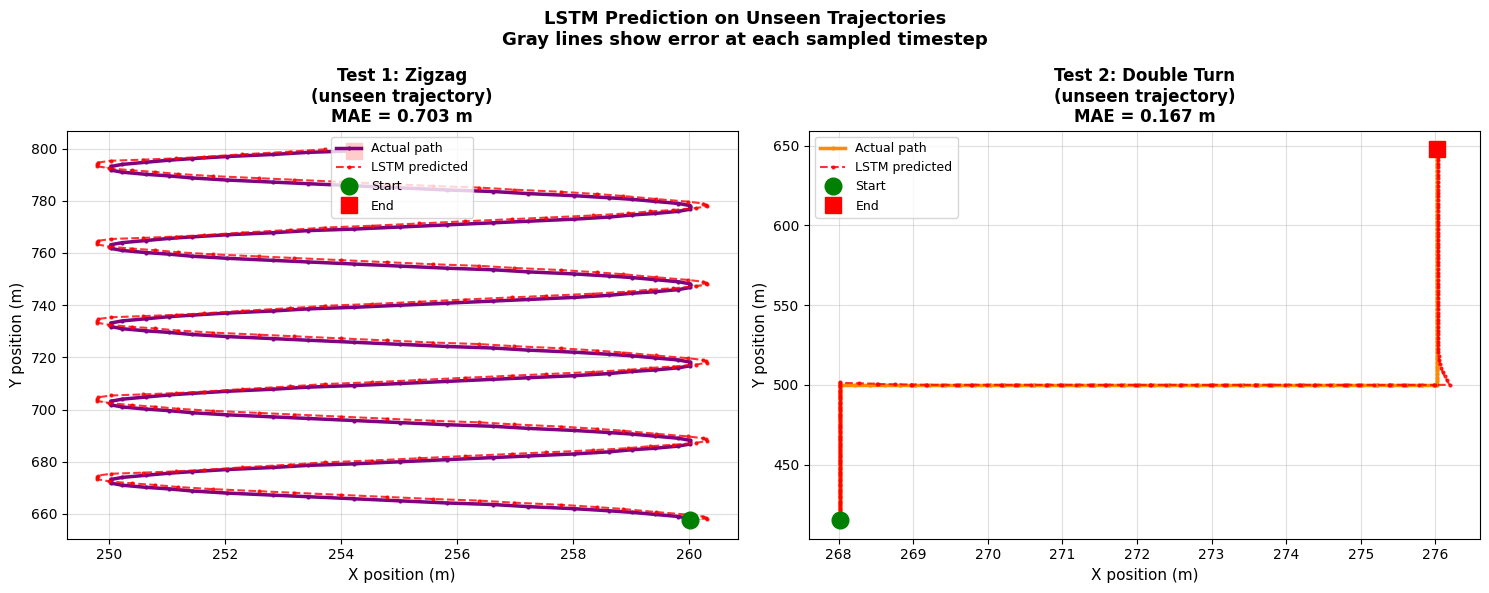

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (pred, true, title, color) in zip(axes, [
    (pred_zz, true_zz, 'Test 1: Zigzag\n(unseen trajectory)', 'purple'),
    (pred_dt, true_dt, 'Test 2: Double Turn\n(unseen trajectory)', 'darkorange'),
]):
    ax.plot(true[:,0], true[:,1], color=color, lw=2.5, ms=4,
            marker='.', label='Actual path', zorder=3)
    ax.plot(pred[:,0], pred[:,1], 'r--', lw=1.5, ms=4,
            marker='.', label='LSTM predicted', zorder=3, alpha=0.8)
    ax.plot(true[0,0],  true[0,1],  'go', ms=12, zorder=5, label='Start')
    ax.plot(true[-1,0], true[-1,1], 'rs', ms=12, zorder=5, label='End')

    # Draw error lines every 15 steps to show magnitude of errors
    for i in range(0, len(pred), 15):
        ax.plot([true[i,0], pred[i,0]], [true[i,1], pred[i,1]],
                'gray', lw=0.8, alpha=0.5)

    err_val = mae(pred, true)
    ax.set_title(f'{title}\nMAE = {err_val:.3f} m', fontsize=12, fontweight='bold')
    ax.set_xlabel('X position (m)', fontsize=11)
    ax.set_ylabel('Y position (m)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle('LSTM Prediction on Unseen Trajectories\n'
             'Gray lines show error at each sampled timestep',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/unseen_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot 2: Prediction Error Over Time
Compares unseen trajectory errors against training trajectory errors

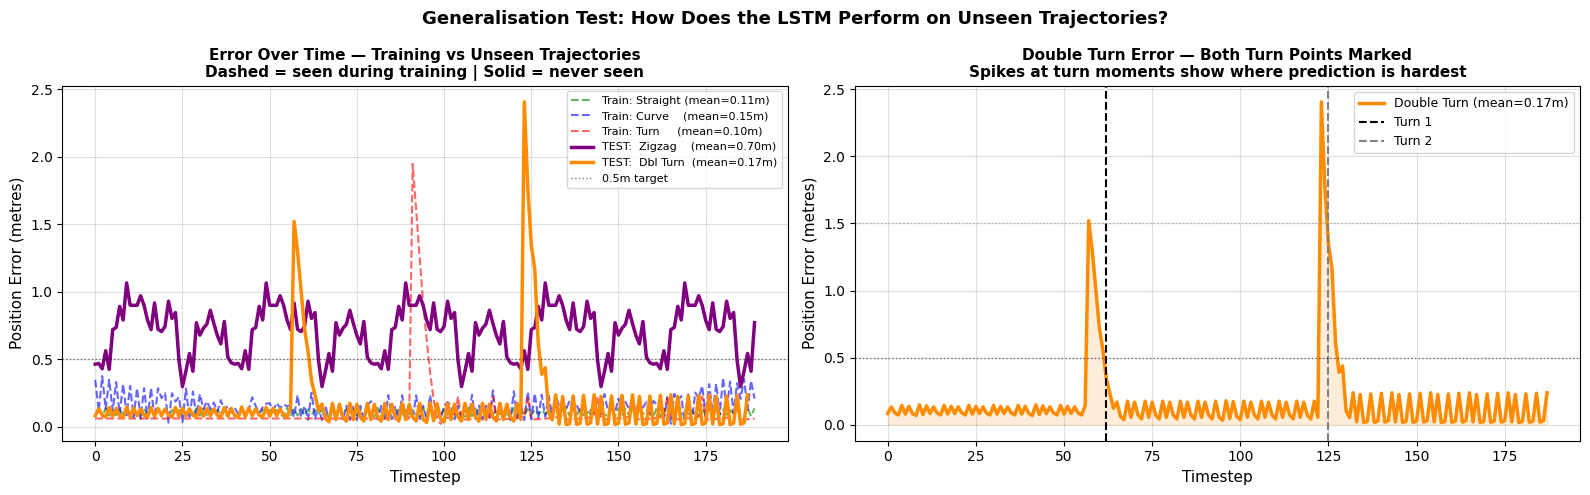

In [25]:
# Load training trajectory errors for comparison
pos_s_train = np.load('../data/trajectory_straight.npy',
                       allow_pickle=True).item()['positions'][:, :2]
pos_c_train = np.load('../data/trajectory_curve.npy',
                       allow_pickle=True).item()['positions'][:, :2]
pos_t_train = np.load('../data/trajectory_turn.npy',
                       allow_pickle=True).item()['positions'][:, :2]

pred_s_tr, true_s_tr = predict_unseen(model, pos_s_train)
pred_c_tr, true_c_tr = predict_unseen(model, pos_c_train)
pred_t_tr, true_t_tr = predict_unseen(model, pos_t_train)

def err_over_time(p, t):
    return np.sqrt(np.sum((p-t)**2, axis=1))

e_s  = err_over_time(pred_s_tr, true_s_tr)
e_c  = err_over_time(pred_c_tr, true_c_tr)
e_t  = err_over_time(pred_t_tr, true_t_tr)
e_zz = err_over_time(pred_zz,   true_zz)
e_dt = err_over_time(pred_dt,   true_dt)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all 5 trajectories on the same axes
axes[0].plot(e_s,  color='green',      lw=1.5, alpha=0.6, ls='--', label=f'Train: Straight (mean={e_s.mean():.2f}m)')
axes[0].plot(e_c,  color='blue',       lw=1.5, alpha=0.6, ls='--', label=f'Train: Curve    (mean={e_c.mean():.2f}m)')
axes[0].plot(e_t,  color='red',        lw=1.5, alpha=0.6, ls='--', label=f'Train: Turn     (mean={e_t.mean():.2f}m)')
axes[0].plot(e_zz, color='purple',     lw=2.5,             label=f'TEST:  Zigzag    (mean={e_zz.mean():.2f}m)')
axes[0].plot(e_dt, color='darkorange', lw=2.5,             label=f'TEST:  Dbl Turn  (mean={e_dt.mean():.2f}m)')
axes[0].axhline(0.5, color='black', ls=':', lw=1, alpha=0.5, label='0.5m target')
axes[0].set_xlabel('Timestep', fontsize=11)
axes[0].set_ylabel('Position Error (metres)', fontsize=11)
axes[0].set_title('Error Over Time — Training vs Unseen Trajectories\n'
                  'Dashed = seen during training | Solid = never seen',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

# Right: mark turn points on double turn
steps_dt = np.arange(len(e_dt))
t1 = len(e_dt)//3
t2 = 2*len(e_dt)//3
axes[1].plot(steps_dt, e_dt, color='darkorange', lw=2.5,
             label=f'Double Turn (mean={e_dt.mean():.2f}m)')
axes[1].axvline(x=t1, color='black', ls='--', lw=1.5, label='Turn 1')
axes[1].axvline(x=t2, color='gray',  ls='--', lw=1.5, label='Turn 2')
axes[1].axhline(0.5, color='black', ls=':', lw=1, alpha=0.5)
axes[1].axhline(1.5, color='gray',  ls=':', lw=1, alpha=0.5)
axes[1].fill_between(steps_dt, e_dt, 0, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Timestep', fontsize=11)
axes[1].set_ylabel('Position Error (metres)', fontsize=11)
axes[1].set_title('Double Turn Error — Both Turn Points Marked\n'
                  'Spikes at turn moments show where prediction is hardest',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

fig.suptitle('Generalisation Test: How Does the LSTM Perform on Unseen Trajectories?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/generalisation_error.png', dpi=150, bbox_inches='tight')
plt.show()

Running beamforming on unseen trajectories...

Zigzag:
  Reactive  — mean SNR: 26.65 dB
  Predictive — mean SNR: 26.59 dB
  SNR gain: -0.057 dB

Double Turn:
  Reactive  — mean SNR: 22.50 dB
  Predictive — mean SNR: 22.61 dB
  SNR gain: +0.106 dB


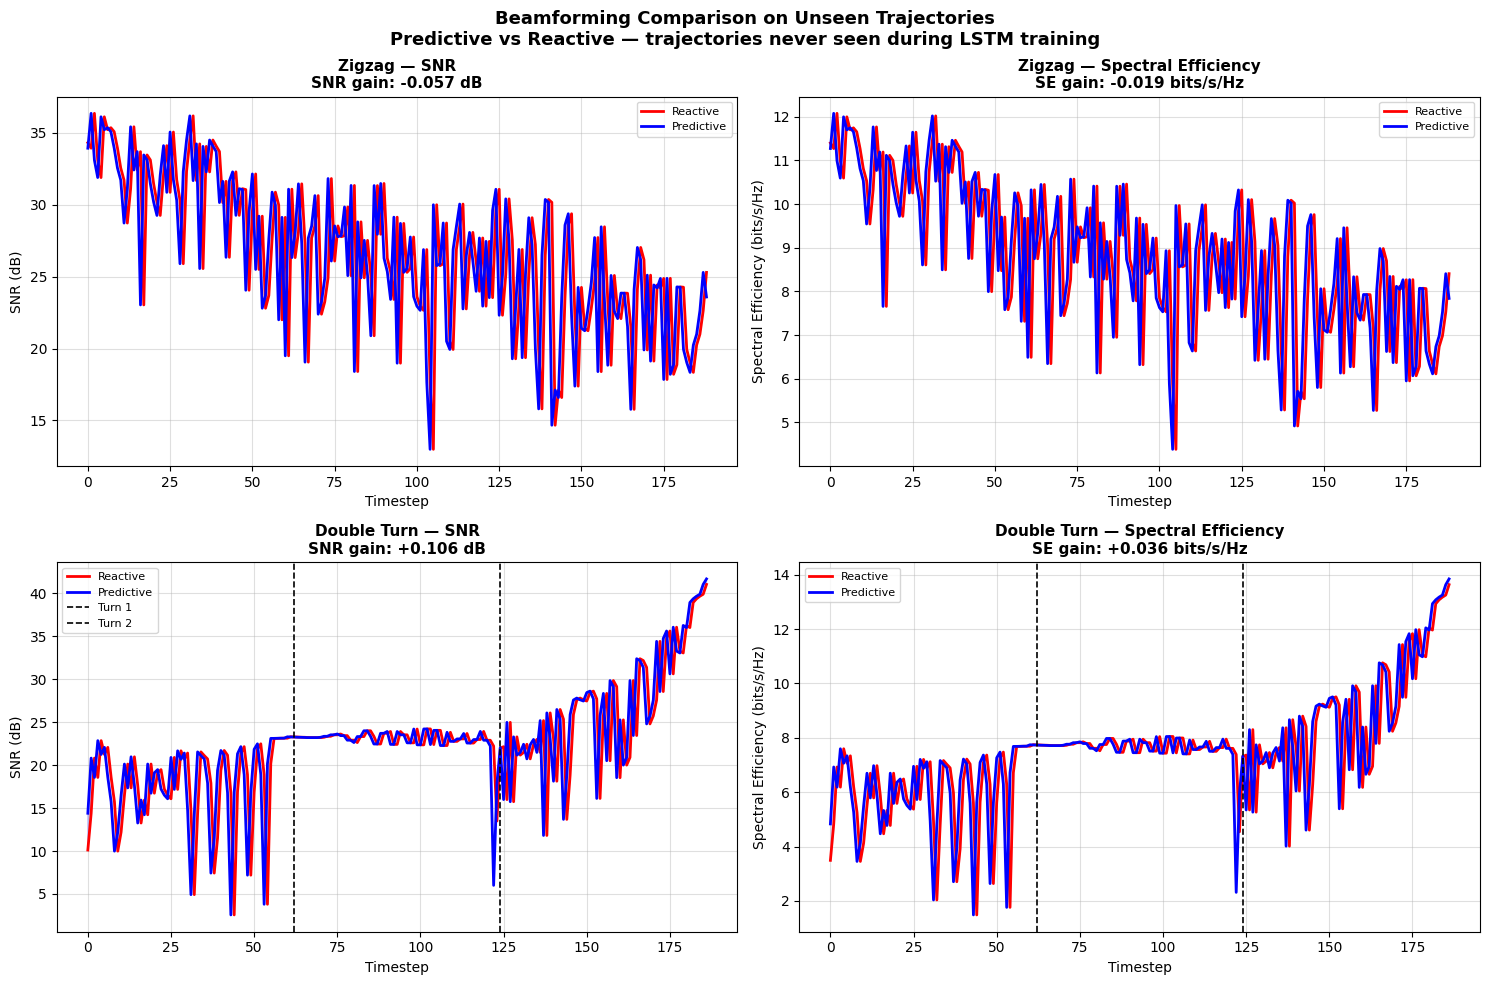

Saved to results/unseen_beamforming.png ✓


In [17]:
# ============================================================
# Cell 8 — Plot 3: Beamforming SNR on Unseen Trajectories
# ============================================================

# Reuse beamforming functions from Week 3
all_H_test   = np.concatenate([H_zz, H_dt], axis=0)
avg_cp       = np.mean(np.abs(all_H_test)**2)
NOISE_POWER  = avg_cp / 100.0

def compute_mrt_weights(H):
    h        = H[:, :, 0]
    h_conj   = np.conj(h)
    norm_val = np.linalg.norm(h_conj)
    if norm_val < 1e-10:
        return np.zeros(h_conj.shape[1], dtype=complex)
    return h_conj[0] / norm_val

def compute_snr(H, w):
    h        = H[:, :, 0]
    received = h @ w
    power    = np.abs(received[0])**2
    return power / NOISE_POWER

def snr_db(snr): return 10 * np.log10(snr + 1e-12)
def spec_eff(snr): return np.log2(1 + snr)

def get_channel_nearest(pos_2d, H_seq, target, t):
    dists = np.sqrt(np.sum((pos_2d[:t+2, :2] - target)**2, axis=1))
    return H_seq[np.argmin(dists)]

def predict_pos(positions_2d, t):
    if t < W: return positions_2d[t]
    anchor = positions_2d[t]
    window = positions_2d[t-W+1:t+1] - anchor
    win_n  = norm(window)
    tensor = torch.tensor(win_n, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        rel_pred = denorm(model(tensor).cpu().numpy()[0])
    return anchor + rel_pred

def run_comparison(pos, H_seq, label):
    pos_2d = pos[:, :2]
    react  = {'snr': [], 'se': []}
    pred_r = {'snr': [], 'se': [], 'pred_error': []}

    for t in range(W, len(pos) - 1):
        # Reactive
        w_r   = compute_mrt_weights(H_seq[t])
        snr_r = compute_snr(H_seq[t], w_r)
        react['snr'].append(snr_db(snr_r))
        react['se'].append(spec_eff(snr_r))

        # Predictive
        pp    = predict_pos(pos_2d, t)
        H_p   = get_channel_nearest(pos_2d, H_seq, pp, t)
        w_p   = compute_mrt_weights(H_p)
        snr_p = compute_snr(H_seq[t+1], w_p)
        pred_r['snr'].append(snr_db(snr_p))
        pred_r['se'].append(spec_eff(snr_p))
        pred_r['pred_error'].append(np.sqrt(np.sum((pp - pos_2d[t+1])**2)))

    gain = np.mean(pred_r['snr']) - np.mean(react['snr'])
    print(f"{label}:")
    print(f"  Reactive  — mean SNR: {np.mean(react['snr']):.2f} dB")
    print(f"  Predictive — mean SNR: {np.mean(pred_r['snr']):.2f} dB")
    print(f"  SNR gain: {gain:+.3f} dB")
    return react, pred_r

print("Running beamforming on unseen trajectories...\n")
react_zz, pred_zz_bf = run_comparison(pos_zz, H_zz, "Zigzag")
print()
react_dt, pred_dt_bf = run_comparison(pos_dt, H_dt, "Double Turn")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

configs = [
    (axes[0,0], axes[0,1], react_zz, pred_zz_bf,
     'Zigzag — SNR', 'Zigzag — Spectral Efficiency', 'purple', None),
    (axes[1,0], axes[1,1], react_dt, pred_dt_bf,
     'Double Turn — SNR', 'Double Turn — Spectral Efficiency', 'darkorange',
     [len(react_dt['snr'])//3, 2*len(react_dt['snr'])//3]),
]

for ax_snr, ax_se, react, pred_bf, title_snr, title_se, color, turn_pts in configs:
    steps = np.arange(len(react['snr']))

    # SNR
    ax_snr.plot(steps, react['snr'],    color='red',  lw=2, label='Reactive')
    ax_snr.plot(steps, pred_bf['snr'],  color='blue', lw=2, label='Predictive')
    ax_snr.fill_between(steps, react['snr'], pred_bf['snr'],
        where=[p > r for p,r in zip(pred_bf['snr'], react['snr'])],
        alpha=0.2, color='blue')
    if turn_pts:
        for tp, lbl in zip(turn_pts, ['Turn 1', 'Turn 2']):
            ax_snr.axvline(x=tp, color='black', ls='--', lw=1.2, label=lbl)
    gain = np.mean(pred_bf['snr']) - np.mean(react['snr'])
    ax_snr.set_title(f'{title_snr}\nSNR gain: {gain:+.3f} dB', fontsize=11, fontweight='bold')
    ax_snr.set_xlabel('Timestep'); ax_snr.set_ylabel('SNR (dB)')
    ax_snr.legend(fontsize=8); ax_snr.grid(True, alpha=0.4)

    # SE
    ax_se.plot(steps, react['se'],   color='red',  lw=2, label='Reactive')
    ax_se.plot(steps, pred_bf['se'], color='blue', lw=2, label='Predictive')
    ax_se.fill_between(steps, react['se'], pred_bf['se'], alpha=0.1, color='blue')
    if turn_pts:
        for tp in turn_pts:
            ax_se.axvline(x=tp, color='black', ls='--', lw=1.2)
    se_gain = np.mean(pred_bf['se']) - np.mean(react['se'])
    ax_se.set_title(f'{title_se}\nSE gain: {se_gain:+.3f} bits/s/Hz', fontsize=11, fontweight='bold')
    ax_se.set_xlabel('Timestep'); ax_se.set_ylabel('Spectral Efficiency (bits/s/Hz)')
    ax_se.legend(fontsize=8); ax_se.grid(True, alpha=0.4)

fig.suptitle('Beamforming Comparison on Unseen Trajectories\n'
             'Predictive vs Reactive — trajectories never seen during LSTM training',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/unseen_beamforming.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/unseen_beamforming.png ✓")

In [ ]:
from IPython.display import display, HTML

rows_html = ''
all_results = [
    ('Straight (training)', 0.107, 25.59, 25.66, '+0.07', 8.52, 8.54, '+0.02'),
    ('Curve (training)',    0.154, 25.12, 25.17, '+0.05', 8.36, 8.38, '+0.02'),
    ('Turn (training)',     0.104, 26.88, 26.96, '+0.08', 8.95, 8.97, '+0.02'),
]

# Add live unseen results
for label, react, pred_bf in [
    ('Zigzag (UNSEEN)',      react_zz, pred_zz_bf),
    ('Double Turn (UNSEEN)', react_dt, pred_dt_bf),
]:
    mae_val = np.mean(pred_bf['pred_error'])
    r_snr   = np.mean(react['snr'])
    p_snr   = np.mean(pred_bf['snr'])
    g_snr   = p_snr - r_snr
    r_se    = np.mean(react['se'])
    p_se    = np.mean(pred_bf['se'])
    g_se    = p_se - r_se
    all_results.append((label, mae_val, r_snr, p_snr,
                        f'{g_snr:+.2f}', r_se, p_se, f'{g_se:+.2f}'))

for label, mae_val, r_snr, p_snr, g_snr, r_se, p_se, g_se in all_results:
    is_unseen = 'UNSEEN' in label
    row_bg    = '#fff9e6' if is_unseen else '#ffffff'
    g_val     = float(g_snr)
    g_color   = '#c8f7c5' if g_val > 0 else '#fdd5d5'
    rows_html += f"""
    <tr style='background:{row_bg}'>
        <td style='padding:8px 12px; font-weight:{"bold" if is_unseen else "normal"}'>{label}</td>
        <td style='padding:8px 12px; text-align:center'>{mae_val:.3f} m</td>
        <td style='padding:8px 12px; text-align:center'>{r_snr:.2f} dB</td>
        <td style='padding:8px 12px; text-align:center'>{p_snr:.2f} dB</td>
        <td style='padding:8px 12px; text-align:center; background:{g_color}'>{g_snr} dB</td>
        <td style='padding:8px 12px; text-align:center'>{r_se:.2f}</td>
        <td style='padding:8px 12px; text-align:center'>{p_se:.2f}</td>
        <td style='padding:8px 12px; text-align:center; background:{g_color}'>{g_se}</td>
    </tr>"""

html = f"""
<h3 style='font-family:sans-serif'>
    🧪 Generalisation Test — Full Results Summary
</h3>
<p style='font-family:sans-serif; font-size:12px; color:#555'>
    White rows = seen during training &nbsp;|&nbsp;
    Yellow rows = never seen during training (generalization test)
</p>
<table style='border-collapse:collapse; font-family:sans-serif; font-size:13px; width:100%'>
    <thead>
        <tr style='background:#2c3e50; color:white'>
            <th style='padding:8px 12px'>Trajectory</th>
            <th style='padding:8px 12px'>LSTM MAE</th>
            <th style='padding:8px 12px'>Reactive SNR</th>
            <th style='padding:8px 12px'>Predictive SNR</th>
            <th style='padding:8px 12px'>SNR Gain</th>
            <th style='padding:8px 12px'>Reactive SE</th>
            <th style='padding:8px 12px'>Predictive SE</th>
            <th style='padding:8px 12px'>SE Gain</th>
        </tr>
    </thead>
    <tbody>{rows_html}</tbody>
</table>
<p style='font-family:sans-serif; font-size:12px; color:#555; margin-top:10px'>
    Green SNR gain = predictive beats reactive &nbsp;|&nbsp;
    SE in bits/s/Hz
</p>"""

display(HTML(html))

Trajectory,LSTM MAE,Reactive SNR,Predictive SNR,SNR Gain,Reactive SE,Predictive SE,SE Gain
Straight (training),0.107 m,25.59 dB,25.66 dB,+0.07 dB,8.52,8.54,+0.02
Curve (training),0.154 m,25.12 dB,25.17 dB,+0.05 dB,8.36,8.38,+0.02
Turn (training),0.104 m,26.88 dB,26.96 dB,+0.08 dB,8.95,8.97,+0.02
Zigzag (UNSEEN),0.705 m,26.65 dB,26.59 dB,-0.06 dB,8.86,8.84,-0.02
Double Turn (UNSEEN),0.168 m,22.50 dB,22.61 dB,+0.11 dB,7.50,7.54,+0.04
